# Sachs dataset: PC, k-PC, Cluster-PC, FCI, Cluster-FCI, and FCI-Tiers

This notebook applies six causal discovery algorithms on the Sachs dataset and plots the Sachs ground-truth graph after each run.

Data shape: (7466, 11)
Node names: ['praf', 'pmek', 'plcg', 'PIP2', 'PIP3', 'p44/42', 'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']


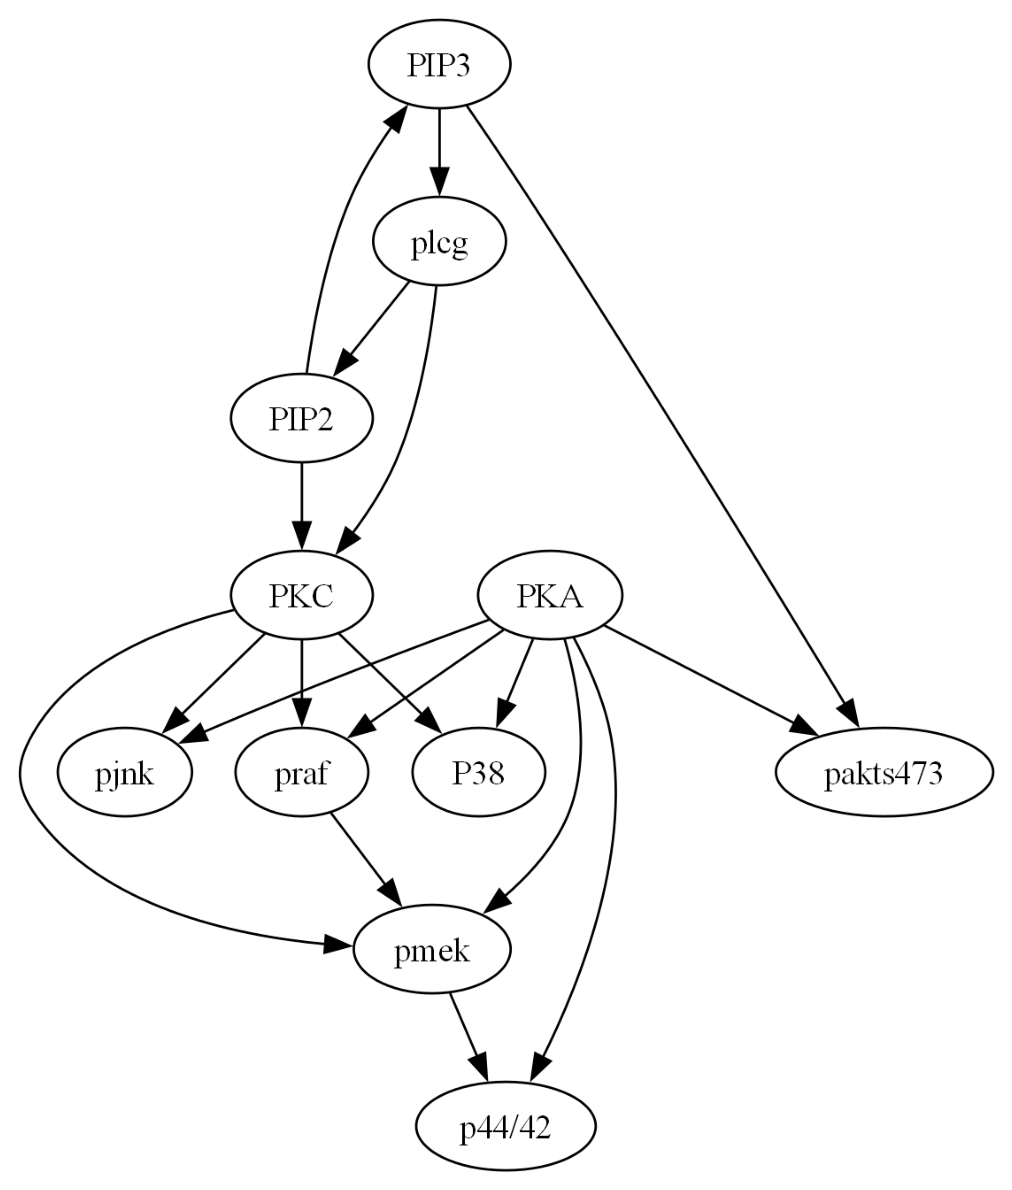

In [141]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx

from cdt.data import load_dataset
from causallearn.graph.GraphClass import CausalGraph
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci

from clustercausal.utils.Utils import make_graph
from clustercausal.algorithms.kPC import kpc
from clustercausal.algorithms.ClusterPC import ClusterPC
from clustercausal.algorithms.ClusterFCI import ClusterFCI
from clustercausal.algorithms.FCITiers import fci_tiers
from clustercausal.clusterdag.ClusterDAG import ClusterDAG

# Load Sachs data and ground truth graph
data, ground_truth = load_dataset("sachs")
node_names = data.columns.tolist()
parent_dict = {node: list(ground_truth.predecessors(node)) for node in node_names}
X = data.to_numpy()

print(f"Data shape: {X.shape}")
print(f"Node names: {node_names}")

def plot_ground_truth_graph(title="Sachs ground truth"):
    fig, ax = plt.subplots(figsize=(10, 8))
    pos = nx.spring_layout(ground_truth, seed=42, k=0.75)
    nx.draw(
        ground_truth,
        pos,
        ax=ax,
        with_labels=True,
        node_size=2200,
        node_color="lightcoral",
        arrowstyle='-|>',
        arrowsize=20,
        width=1.5,
        connectionstyle='arc3,rad=0.1',
    )
    ax.set_title(title)
    ax.axis("off")
    plt.show()
true_graph, _ = make_graph(node_names, parent_dict)
true_graph.draw_pydot_graph()
# plot_ground_truth_graph("Sachs ground truth (reference)")

In [142]:
data

,praf,pmek,plcg,PIP2,PIP3,p44/42,pakts473,PKA,PKC,P38,pjnk
0,26.4,13.20,8.82,18.30,58.80,6.61,17.0,414.0,17.00,44.90,40.00
1,35.9,16.50,12.30,16.80,8.13,18.60,32.5,352.0,3.37,16.50,61.50
2,59.4,44.10,14.60,10.20,13.00,14.90,32.5,403.0,11.40,31.90,19.50
3,73.0,82.80,23.10,13.50,1.29,5.83,11.8,528.0,13.70,28.60,23.10
4,33.7,19.80,5.19,9.73,24.80,21.10,46.1,305.0,4.66,25.70,81.30
...,...,...,...,...,...,...,...,...,...,...,...
7461,49.1,12.40,32.80,27.90,22.70,11.70,38.2,1144.0,1.00,2.55,1.00
7462,23.3,4.61,17.80,22.10,14.90,48.70,67.3,922.0,1.00,9.82,1.00
7463,28.1,4.49,18.80,20.20,10.20,3.08,21.9,730.0,1.00,1.75,2.00
7464,34.6,7.10,5.73,20.70,15.10,32.20,41.4,813.0,44.50,1382.00,2.44


Cluster mapping used for cluster-based methods:
  PIP3, plcg, PIP2: ['PIP3', 'plcg', 'PIP2']
  PKA: ['PKA']
  PKC, pjnk, praf, pakts473, P38: ['PKC', 'pjnk', 'praf', 'pakts473', 'P38']
  pmek, p44/42: ['pmek', 'p44/42']
Cluster edges: [('PIP3, plcg, PIP2', 'PKC, pjnk, praf, pakts473, P38'), ('PKA', 'PKC, pjnk, praf, pakts473, P38'), ('PKC, pjnk, praf, pakts473, P38', 'pmek, p44/42')]


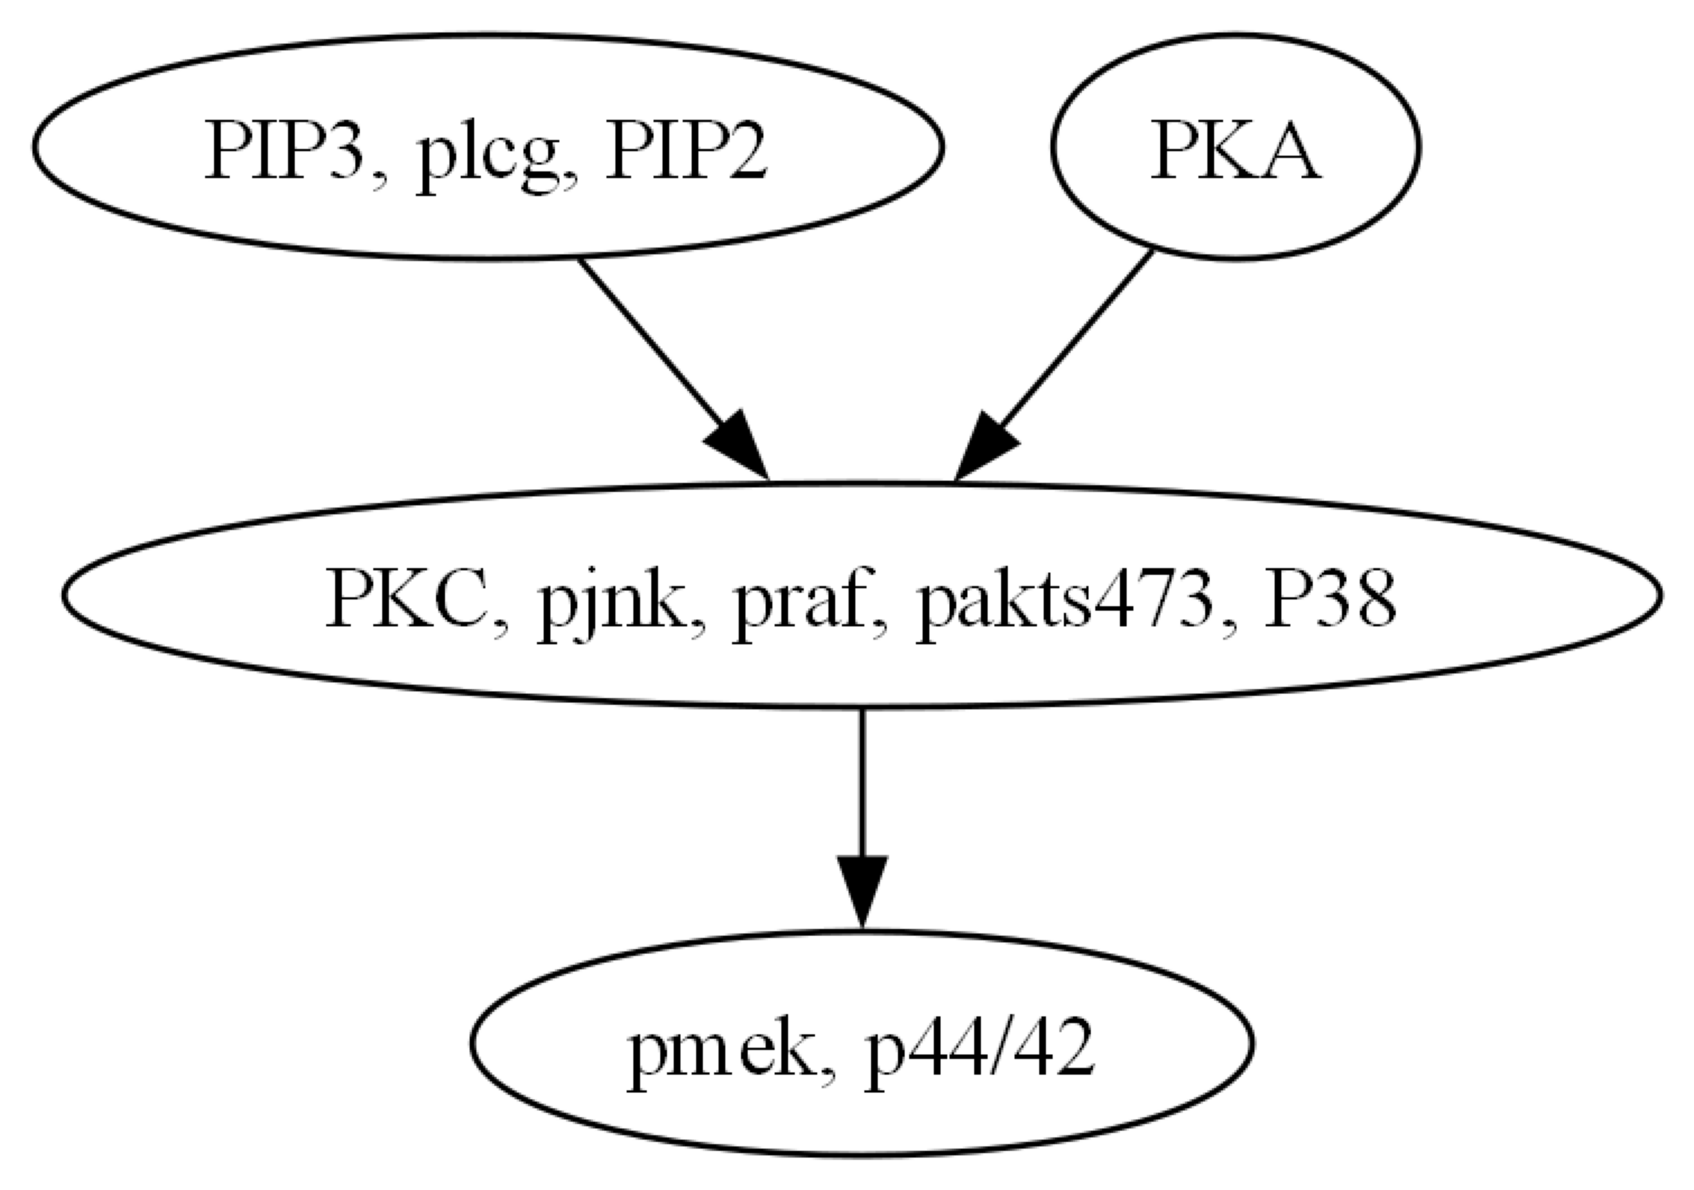

In [143]:
cluster_mapping = {
    'PIP3, plcg, PIP2': ['PIP3', 'plcg', 'PIP2'],
    'PKA': ['PKA'],
    'PKC, pjnk, praf, pakts473, P38': ['PKC', 'pjnk', 'praf', 'pakts473', 'P38'],
    'pmek, p44/42': ['pmek', 'p44/42'],
}
cluster_edges = [
    ('PIP3, plcg, PIP2', 'PKC, pjnk, praf, pakts473, P38'),
    ('PKA', 'PKC, pjnk, praf, pakts473, P38'),
    ('PKC, pjnk, praf, pakts473, P38', 'pmek, p44/42'),
    ]
def make_sachs_cluster_dag():
    return ClusterDAG(
        cluster_mapping=cluster_mapping,
        cluster_edges=cluster_edges,
        node_names=node_names,
    )
print("Cluster mapping used for cluster-based methods:")
for cluster_name, members in cluster_mapping.items():
    print(f"  {cluster_name}: {members}")
print(f"Cluster edges: {cluster_edges}")
make_sachs_cluster_dag().draw_cluster_graph()

In [144]:
# # Build tiers from the Sachs graph to create a compatible ClusterDAG
# check_graph = ground_truth.copy()

# if nx.is_directed_acyclic_graph(check_graph):
#     topo_generations = [list(gen) for gen in nx.topological_generations(check_graph)]
#     node_to_tier = {
#         node: idx + 1
#         for idx, generation in enumerate(topo_generations)
#         for node in generation
#     }
# else:
#     scc_graph = nx.condensation(check_graph)
#     topo_scc_generations = [list(gen) for gen in nx.topological_generations(scc_graph)]
#     node_to_tier = {}
#     for idx, scc_generation in enumerate(topo_scc_generations):
#         for scc_node in scc_generation:
#             for node in scc_graph.nodes[scc_node]["members"]:
#                 node_to_tier[node] = idx + 1
#     print("Ground-truth graph has cycles; tiers were built from SCC condensation.")

# # Keep node order consistent with data columns
# cluster_mapping = {}
# for tier_idx in sorted(set(node_to_tier.values())):
#     tier_nodes = [node for node in node_names if node_to_tier.get(node) == tier_idx]
#     if tier_nodes:
#         cluster_mapping[f"C{tier_idx}"] = tier_nodes

# # Fully ordered tier edges C_i -> C_j for i < j
# cluster_names = list(cluster_mapping.keys())
# cluster_edges = [
#     (cluster_names[i], cluster_names[j])
#     for i in range(len(cluster_names))
#     for j in range(i + 1, len(cluster_names))
# ]

# def make_sachs_cluster_dag():
#     return ClusterDAG(
#         cluster_mapping=cluster_mapping,
#         cluster_edges=cluster_edges,
#         node_names=node_names,
#     )

# print("Cluster mapping used for cluster-based methods:")
# for cluster_name, members in cluster_mapping.items():
#     print(f"  {cluster_name}: {members}")
# print(f"Cluster edges: {cluster_edges}")
# make_sachs_cluster_dag().draw_cluster_graph()

In [145]:
alpha = 0.01
# indep_test = "kci"
indep_test = "fisherz"
import numpy as np
np.random.seed(42)
# indices = np.random.choice(X.shape[0], size=300, replace=False)
# X = X[indices]

PC estimated graph:


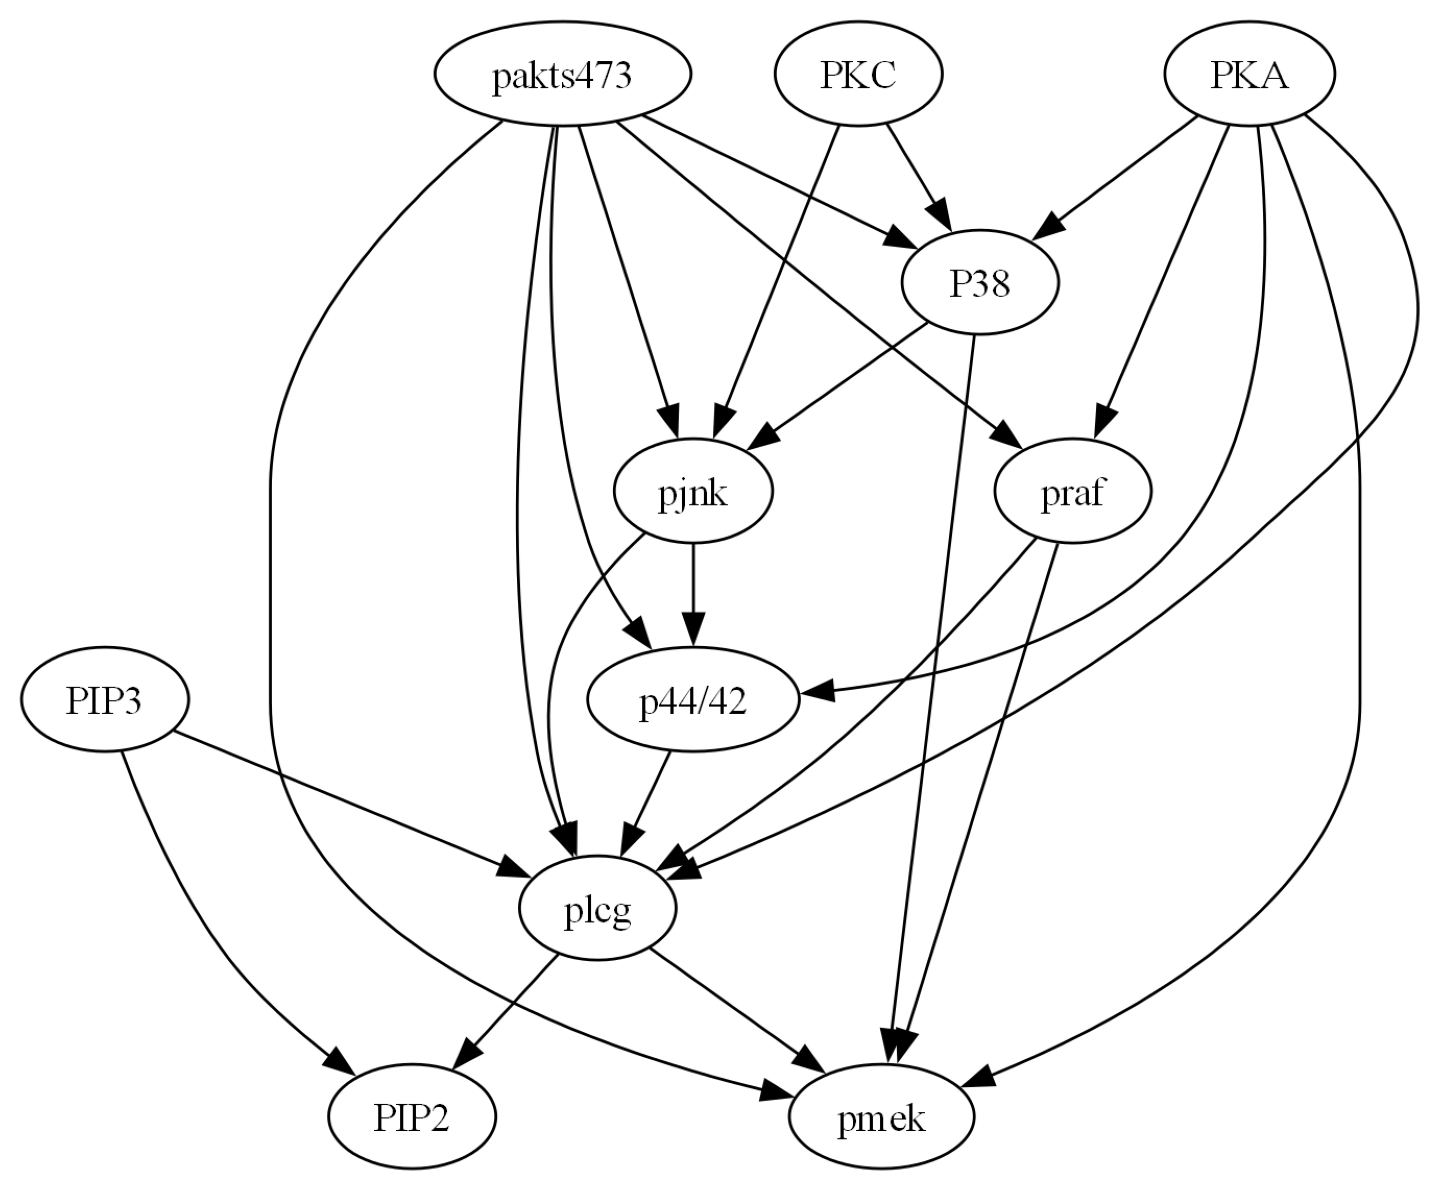

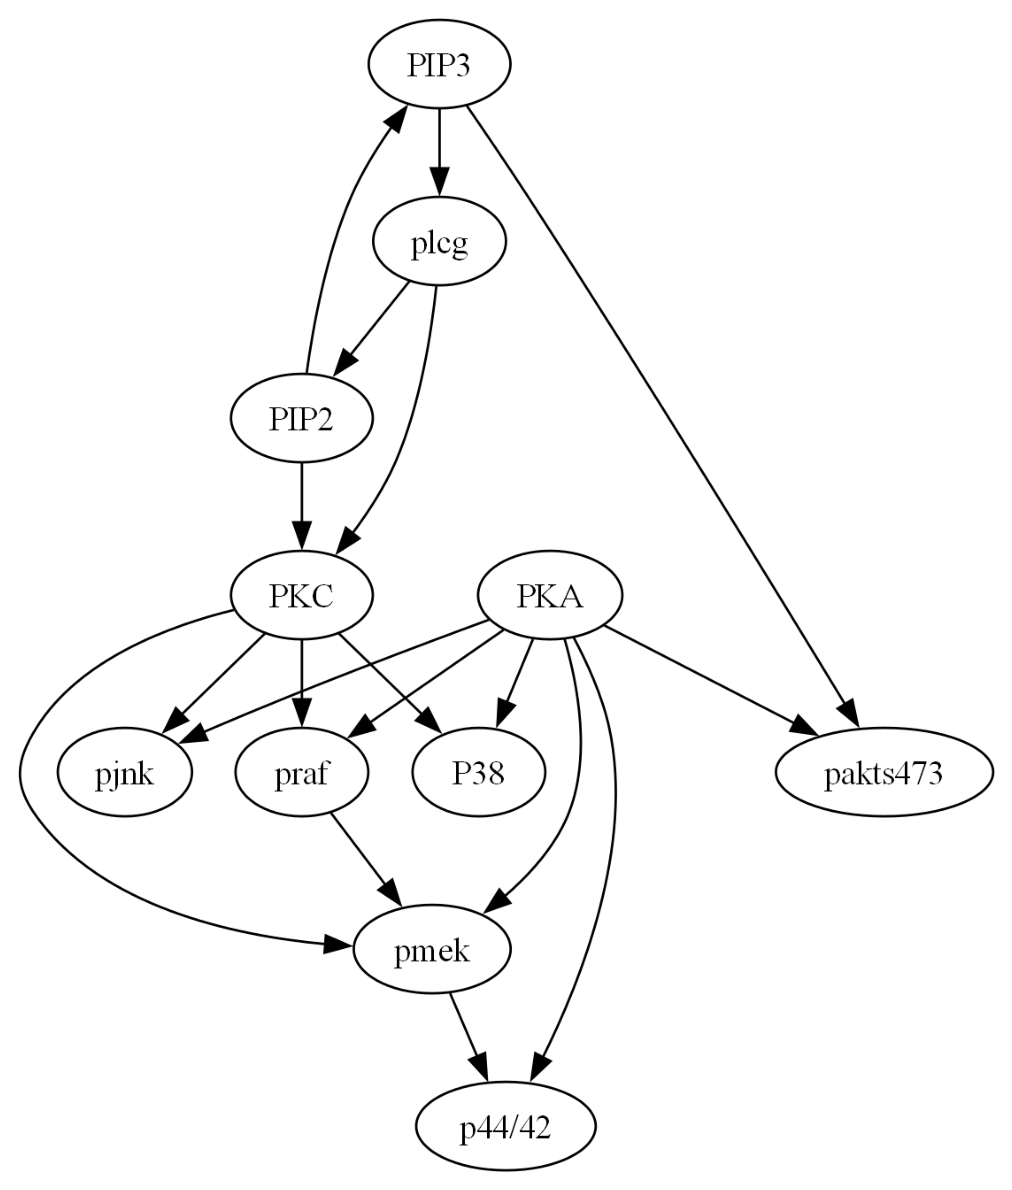

In [146]:
# PC
pc_est_graph = pc(X, alpha=alpha, indep_test = indep_test, verbose=False, show_progress=False, node_names=node_names)
print("PC estimated graph:")
pc_est_graph.draw_pydot_graph()
true_graph.draw_pydot_graph()

## k-PC

kPC estimated graph with k=2:


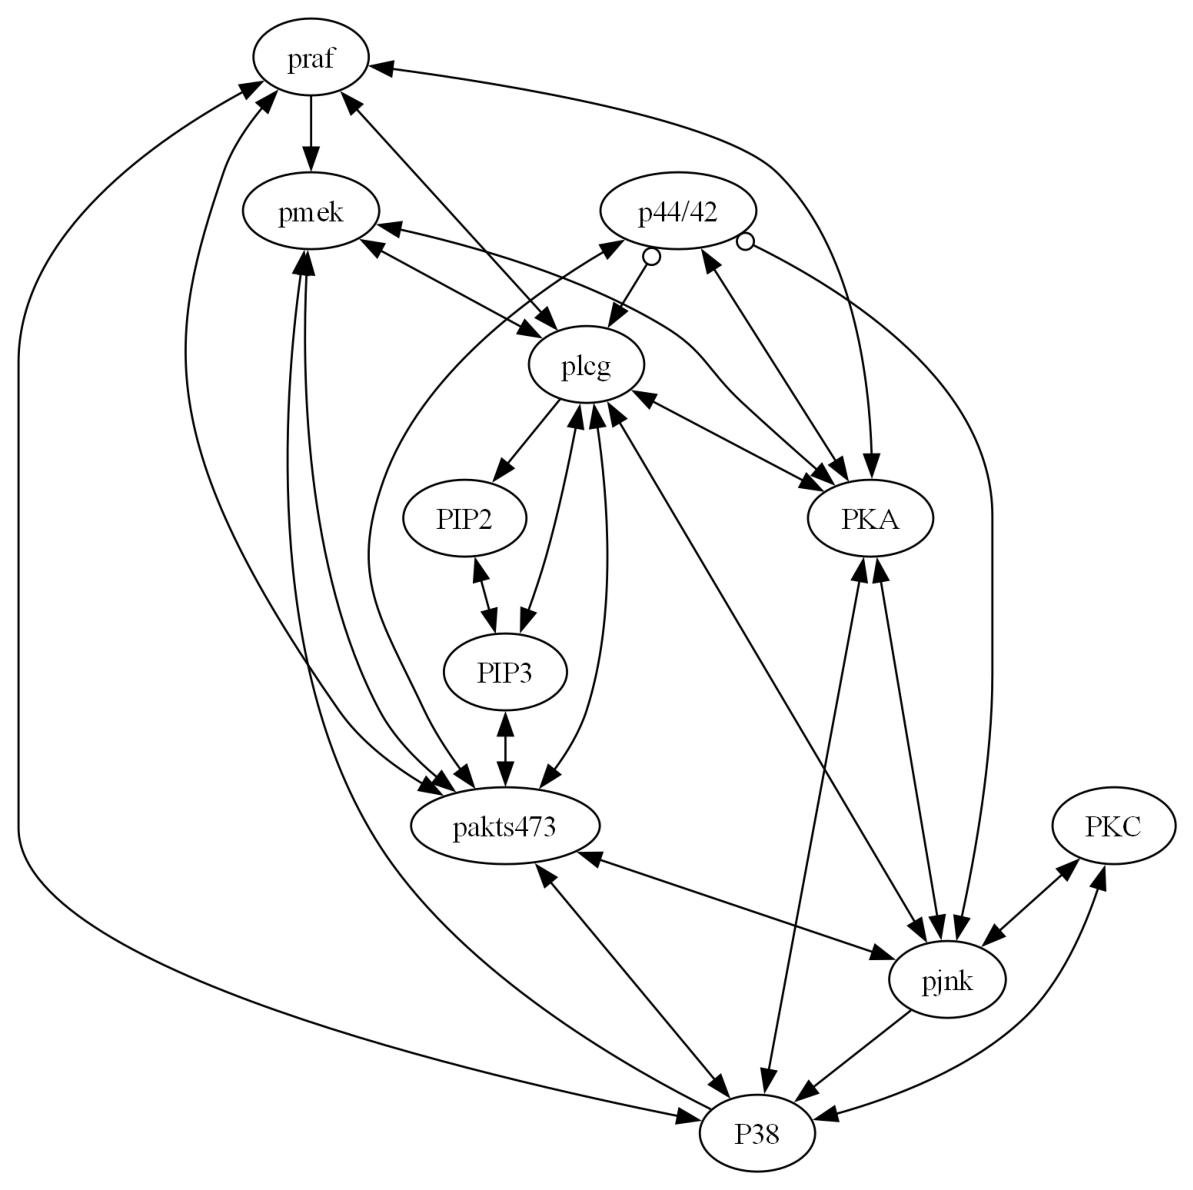

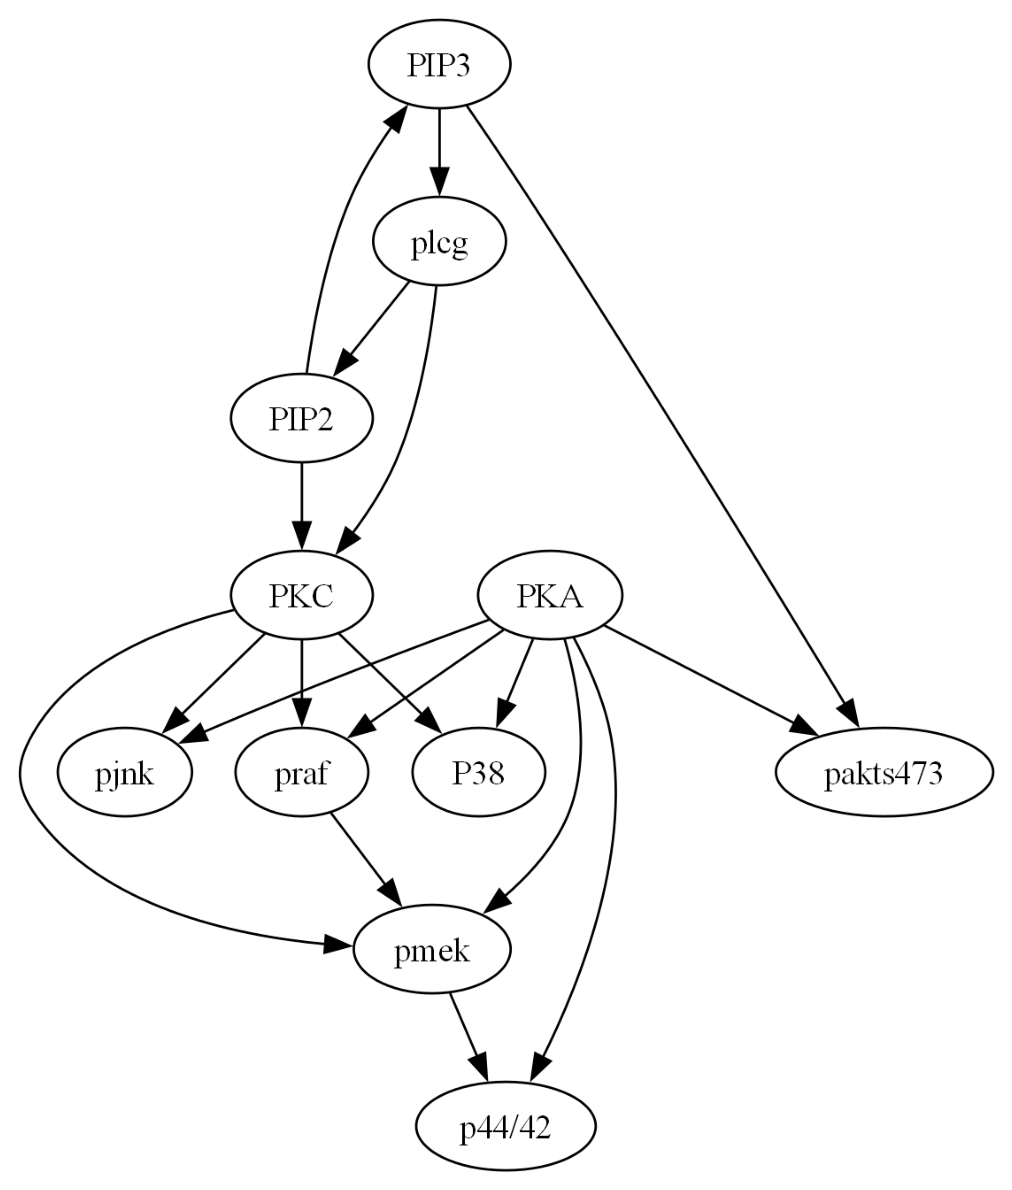

In [147]:
k = 2
kpc_est_graph = kpc(
    X,
    k=k,
    alpha=alpha,
    verbose=False,
    show_progress=False,
    node_names=node_names,
    indep_test=indep_test,
)
print(f"kPC estimated graph with k={k}:")
kpc_est_graph.draw_pydot_graph()
true_graph.draw_pydot_graph()

## Cluster-PC

Duration of algorithm was 0.05sec
ClusterPC estimated graph:


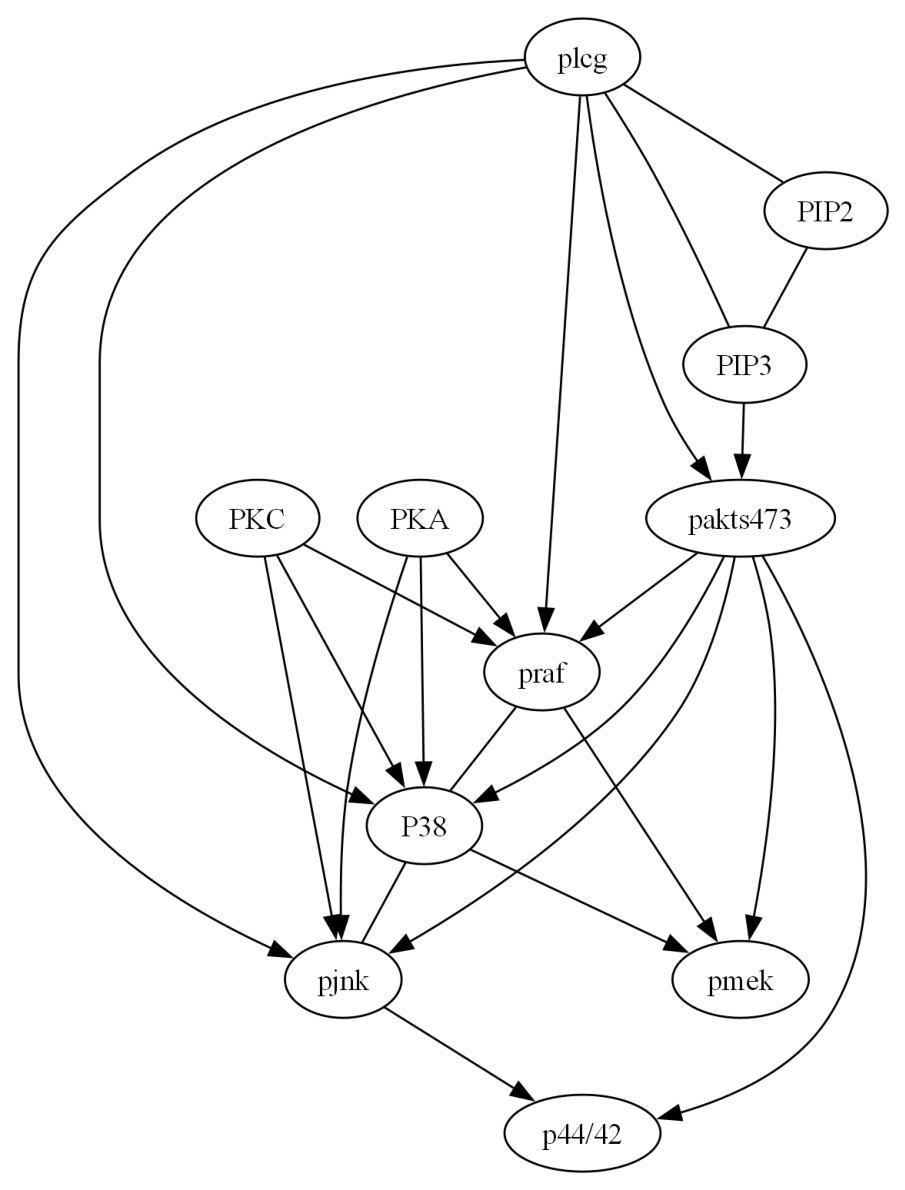

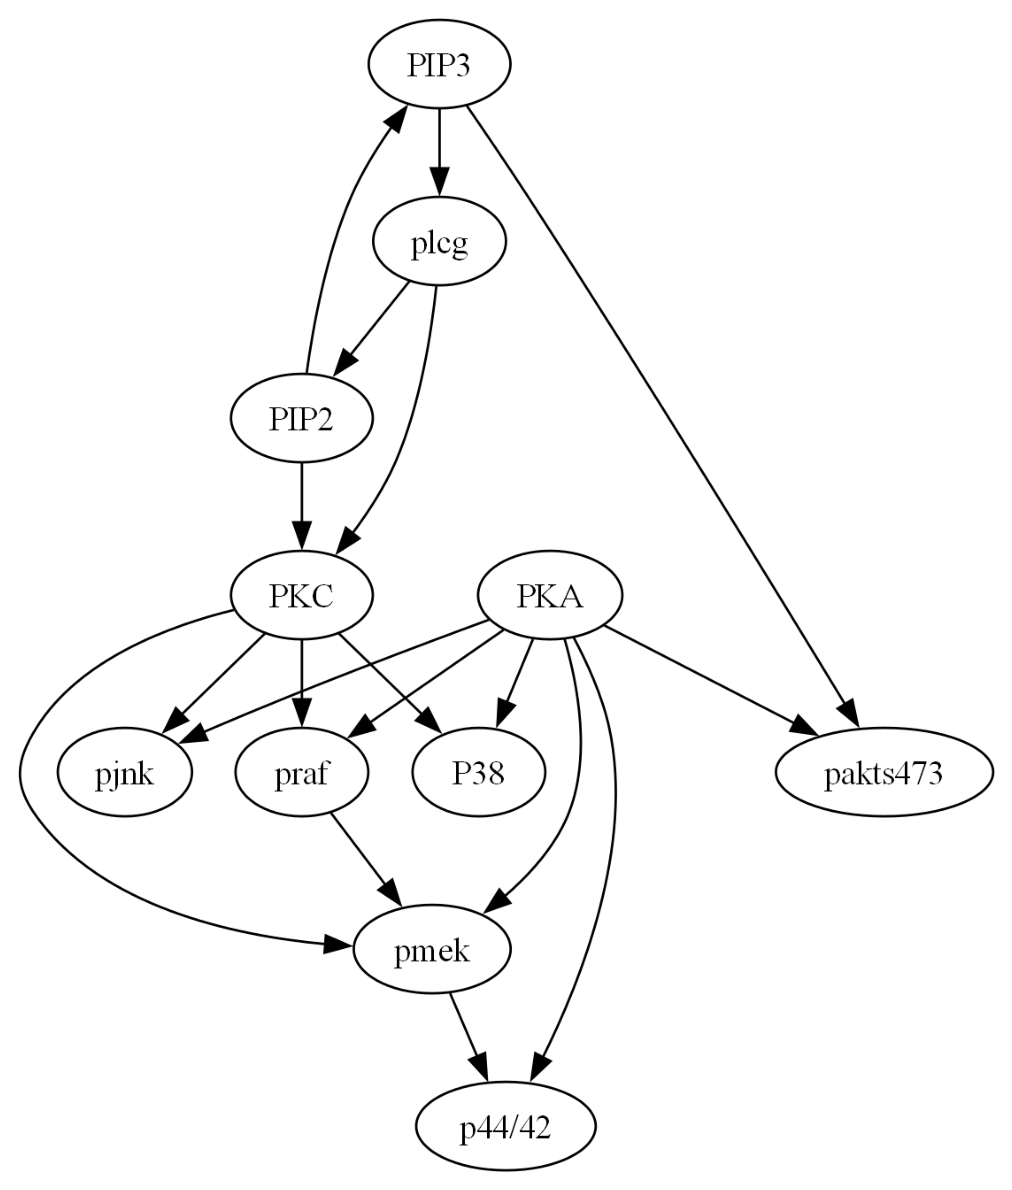

In [148]:
cluster_dag_pc = make_sachs_cluster_dag()
cluster_pc = ClusterPC(
    cdag=cluster_dag_pc,
    data=X,
    alpha=alpha,
    indep_test=indep_test,
    verbose=False,
    show_progress=False,
    stable=True,
)
cluster_pc_est_graph = cluster_pc.run()
print("ClusterPC estimated graph:")
cluster_pc_est_graph.draw_pydot_graph()
true_graph.draw_pydot_graph()

In [149]:
# Evaluator comparison for PC variants (PC, k-PC, Cluster-PC)
import pandas as pd
from clustercausal.experiments.Evaluator import Evaluator
from clustercausal.utils.Utils import nx_to_causallearn_adjmat

truth_cg = CausalGraph(no_of_var=len(node_names), node_names=node_names)
truth_nx_adj = nx.to_numpy_array(ground_truth, nodelist=node_names, dtype=int)
truth_cg.G.graph = nx_to_causallearn_adjmat(truth_nx_adj)

pc_variant_graphs = {
    "PC": pc_est_graph,
    "k-PC": kpc_est_graph,
    "Cluster-PC": cluster_pc_est_graph,
}

rows = []
for method_name, est_cg in pc_variant_graphs.items():
    evaluator = Evaluator(truth=truth_cg.G, est=est_cg.G)
    adj_conf, arrow_conf, shd, _ = evaluator.get_causallearn_metrics(sid=False)
    rows.append(
        {
            "Method": method_name,
            "Adj. precision": adj_conf["precision"],
            "Adj. recall": adj_conf["recall"],
            "Adj. F1-score": adj_conf["f1_score"],
            "Arrow precision": arrow_conf["precision"],
            "Arrow recall": arrow_conf["recall"],
            "Arrow F1-score": arrow_conf["f1_score"],
            "SHD": shd,
        }
    )

pc_variant_eval = pd.DataFrame(rows).set_index("Method")
display(
    pc_variant_eval.style.format(
        {
            "Adj. precision": "{:.1%}",
            "Adj. recall": "{:.1%}",
            "Adj. F1-score": "{:.1%}",
            "Arrow precision": "{:.1%}",
            "Arrow recall": "{:.1%}",
            "Arrow F1-score": "{:.1%}",
            "SHD": "{:.1f}",
        }
    )
)

,Adj. precision,Adj. recall,Adj. F1-score,Arrow precision,Arrow recall,Arrow F1-score,SHD
Method,,,,,,,
PC,41.7%,55.6%,47.6%,37.5%,50.0%,42.9%,23.0
k-PC,44.4%,66.7%,53.3%,25.0%,66.7%,36.4%,31.0
Cluster-PC,45.8%,61.1%,52.4%,42.1%,44.4%,43.2%,20.0


## FCI

Depth=7, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 1831.79it/s]


X3 --> X4
X7 --> X11
X10 --> X11
FCI estimated graph:


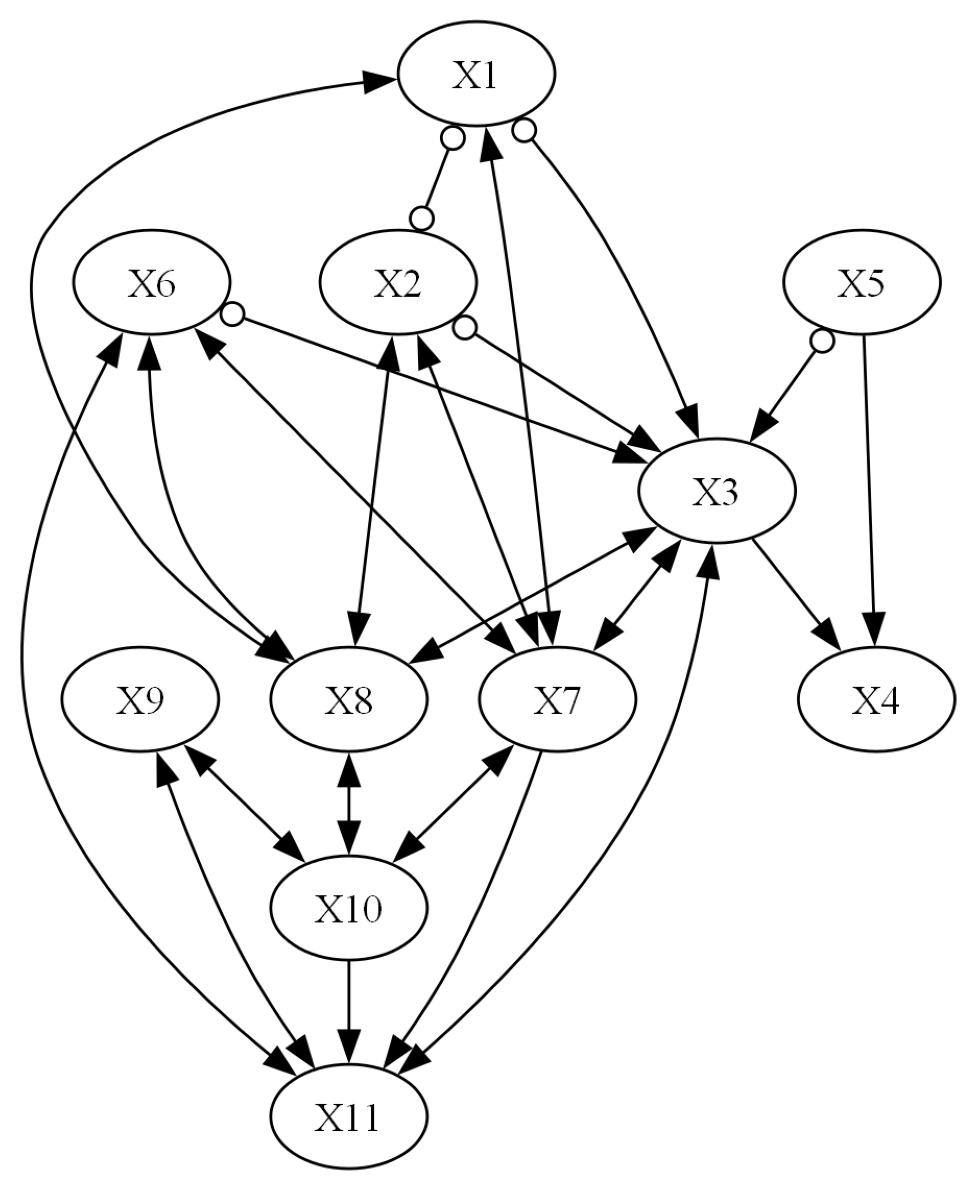

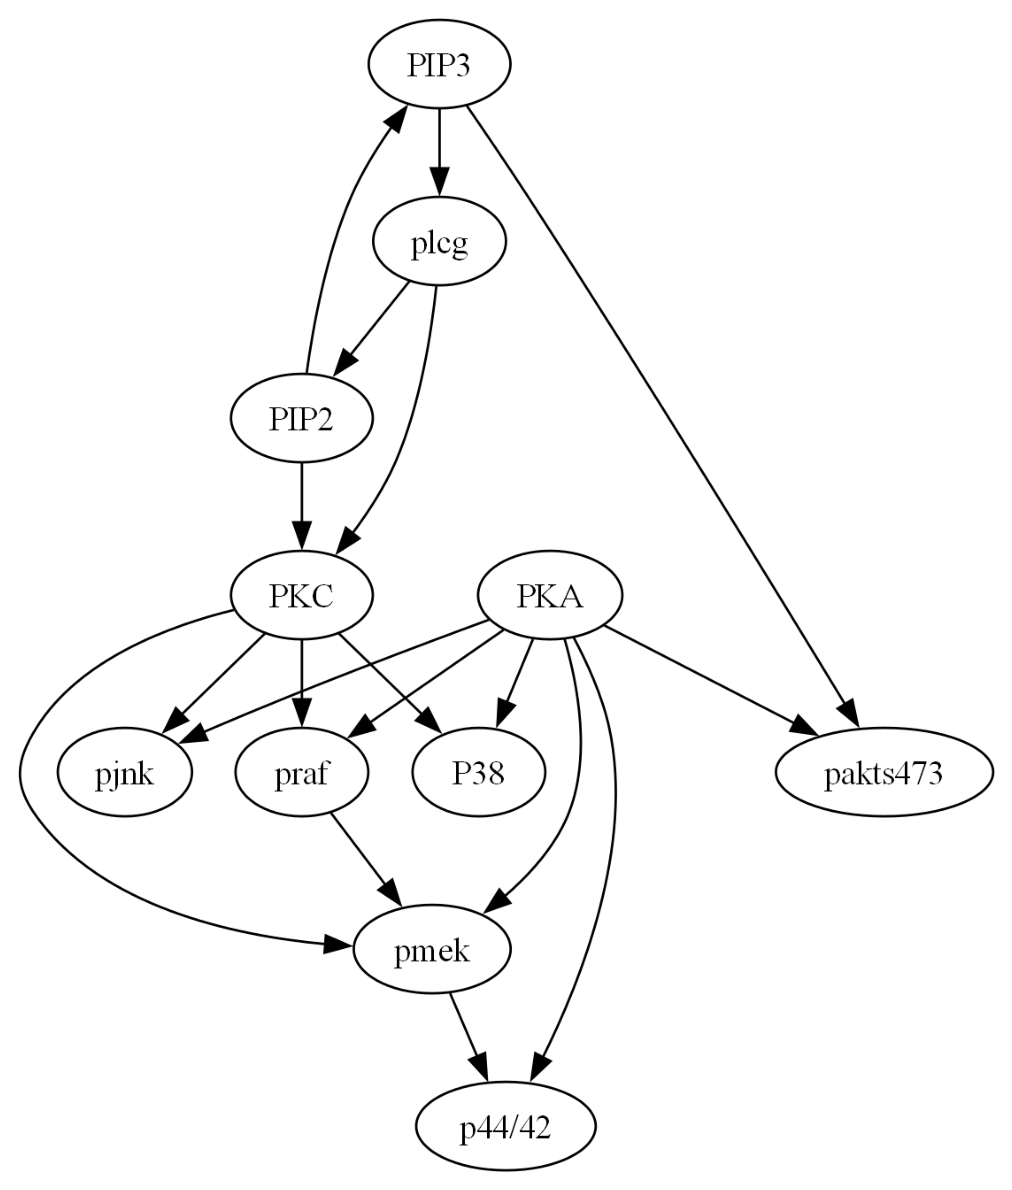

In [150]:
fci_graph, fci_edges = fci(
    X,
    alpha=alpha,
    verbose=False,
    show_progress=False,
)

# Wrap FCI result for consistent plotting API
fci_est_graph = CausalGraph(no_of_var=len(node_names), node_names=node_names)
fci_est_graph.G = fci_graph
print("FCI estimated graph:")
fci_est_graph.draw_pydot_graph()
true_graph.draw_pydot_graph()

## Cluster-FCI

praf --> pmek
pakts473 --> pmek
P38 --> pmek
pakts473 --> p44/42
pjnk --> p44/42
pakts473 --> P38
pakts473 --> pjnk
Cluster-FCI estimated graph:


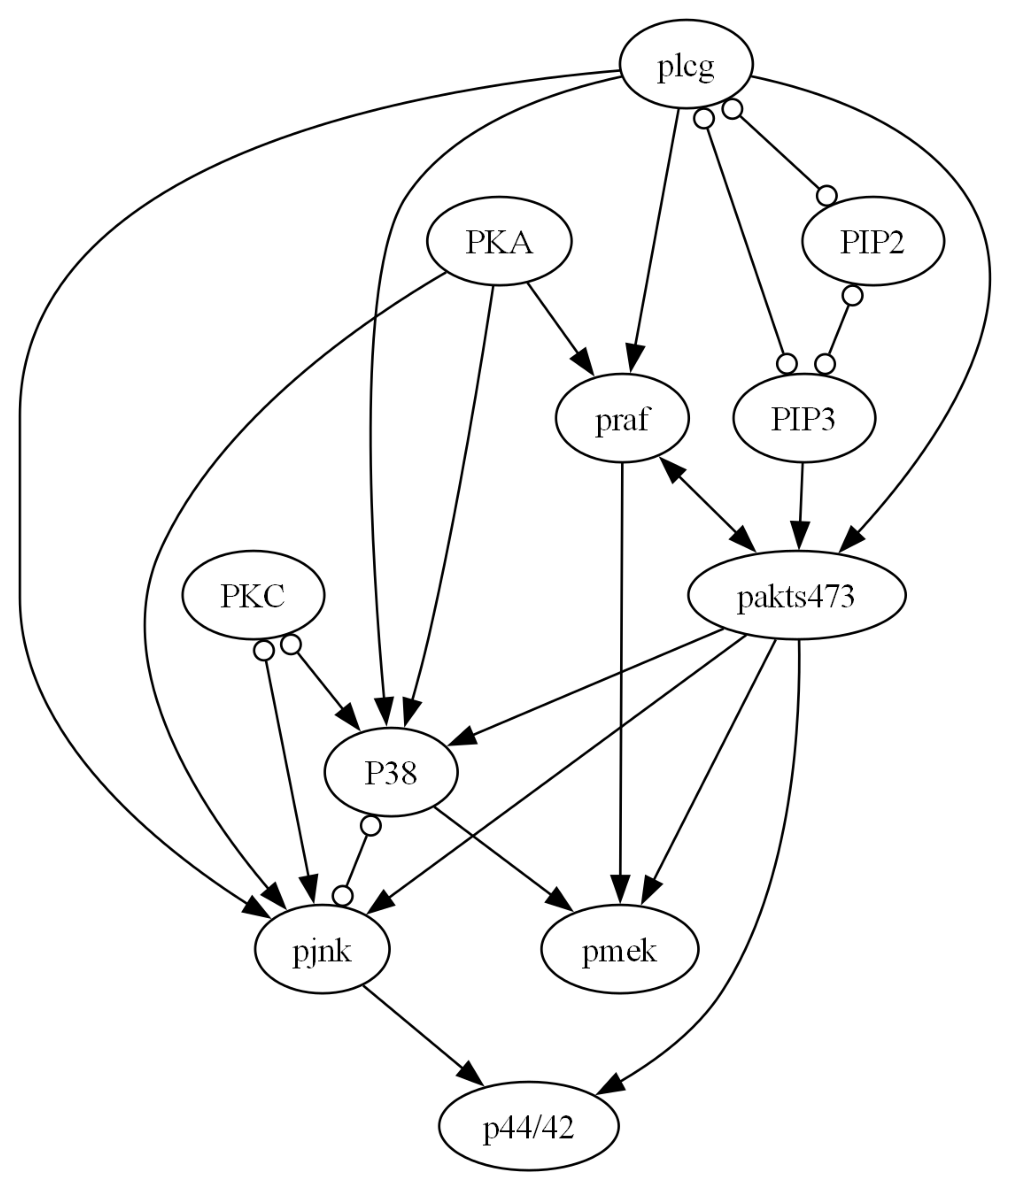

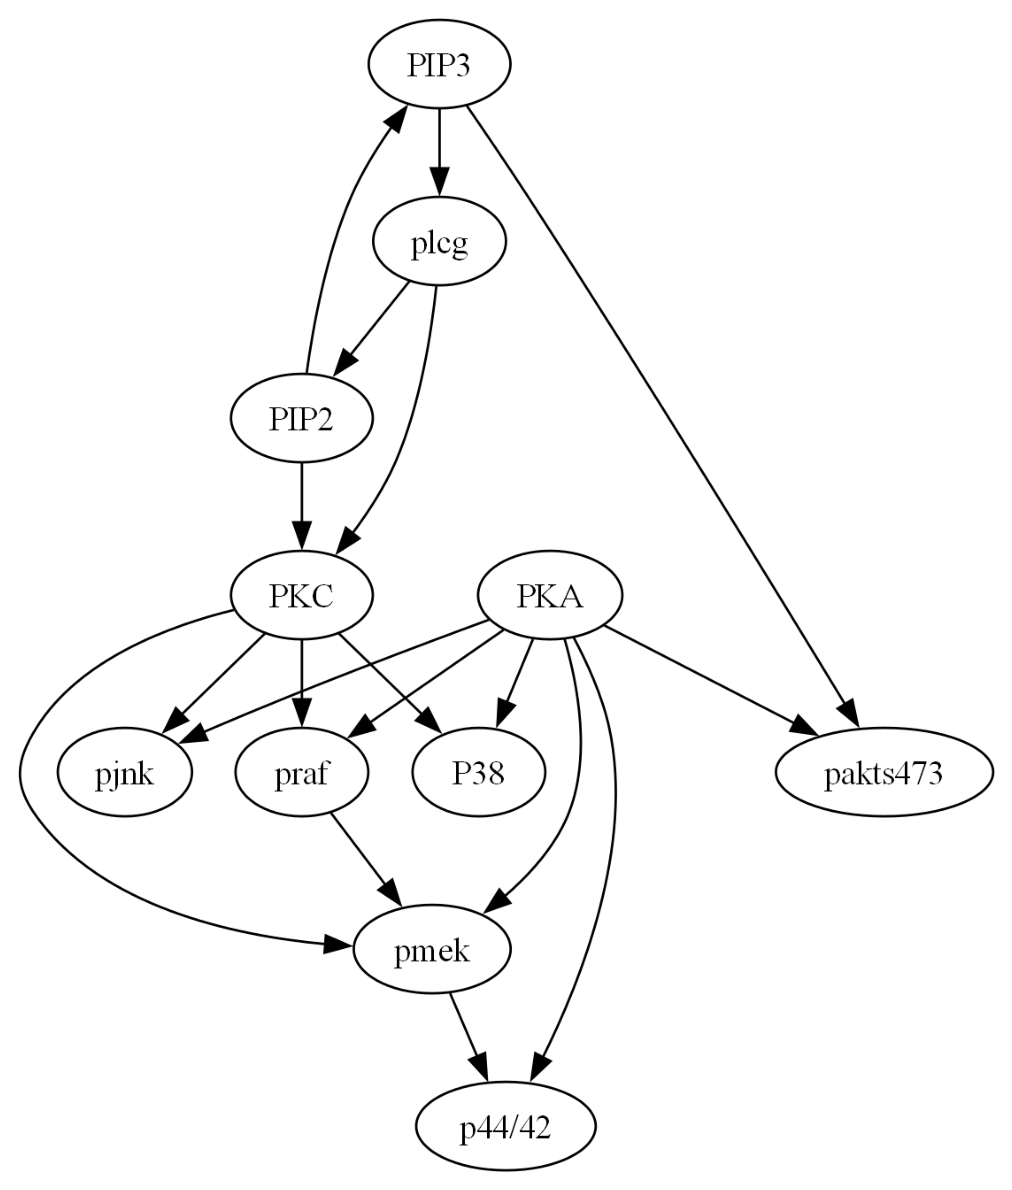

In [151]:
cluster_dag_fci = make_sachs_cluster_dag()
cluster_fci = ClusterFCI(
    cdag=cluster_dag_fci,
    dataset=X,
    alpha=alpha,
    verbose=False,
    show_progress=False,
)
cluster_fci_est_graph, cluster_fci_edges = cluster_fci.run()
print("Cluster-FCI estimated graph:")
cluster_fci_est_graph.draw_pydot_graph()
true_graph.draw_pydot_graph()

## FCI-Tiers

Depth=7, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 1571.54it/s]


praf --> pmek
pakts473 --> praf
PKA --> praf
pakts473 --> pmek
PKA --> pmek
P38 --> pmek
pakts473 --> p44/42
PKA --> p44/42
pjnk --> p44/42
PKA --> P38
P38 --> pjnk
FCI-Tiers estimated graph:


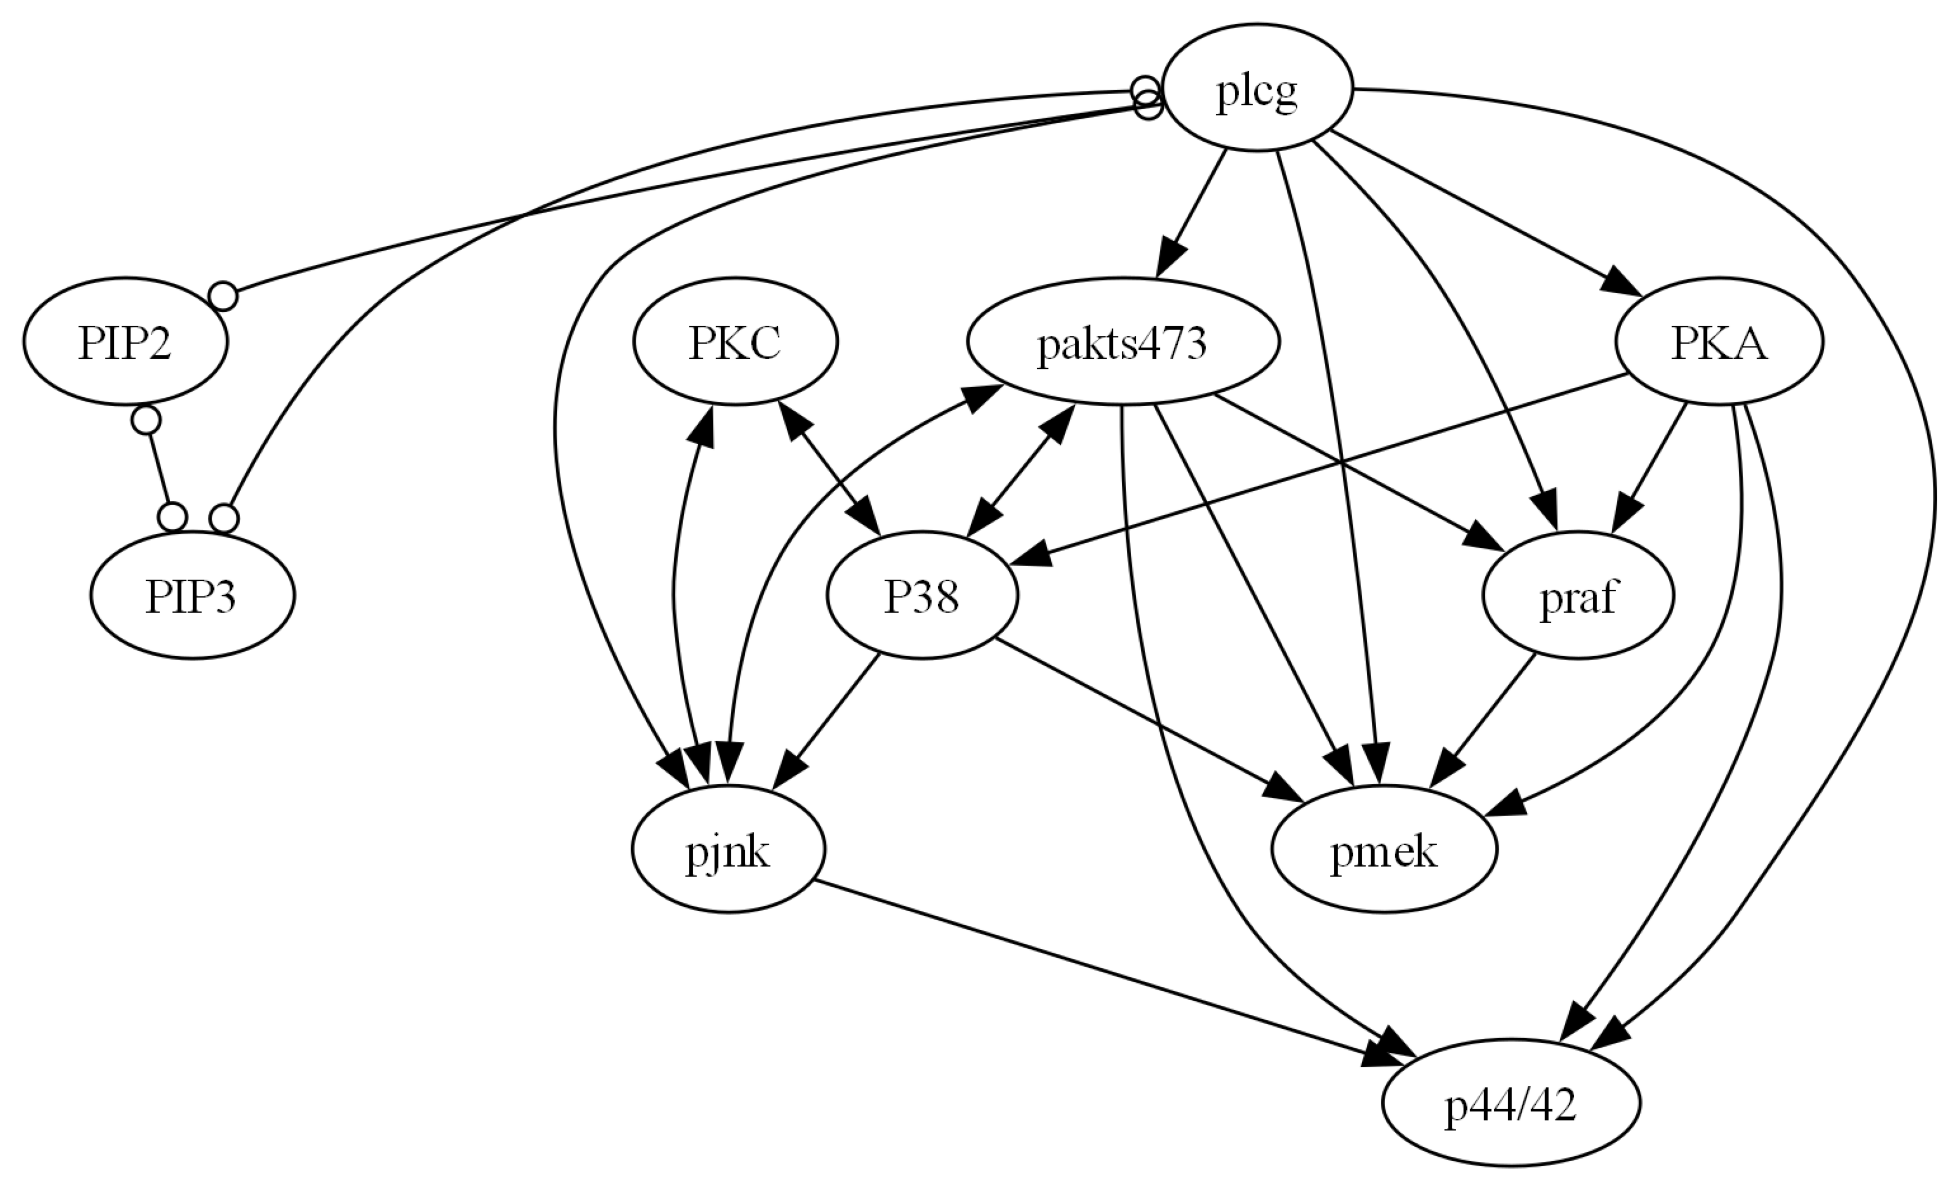

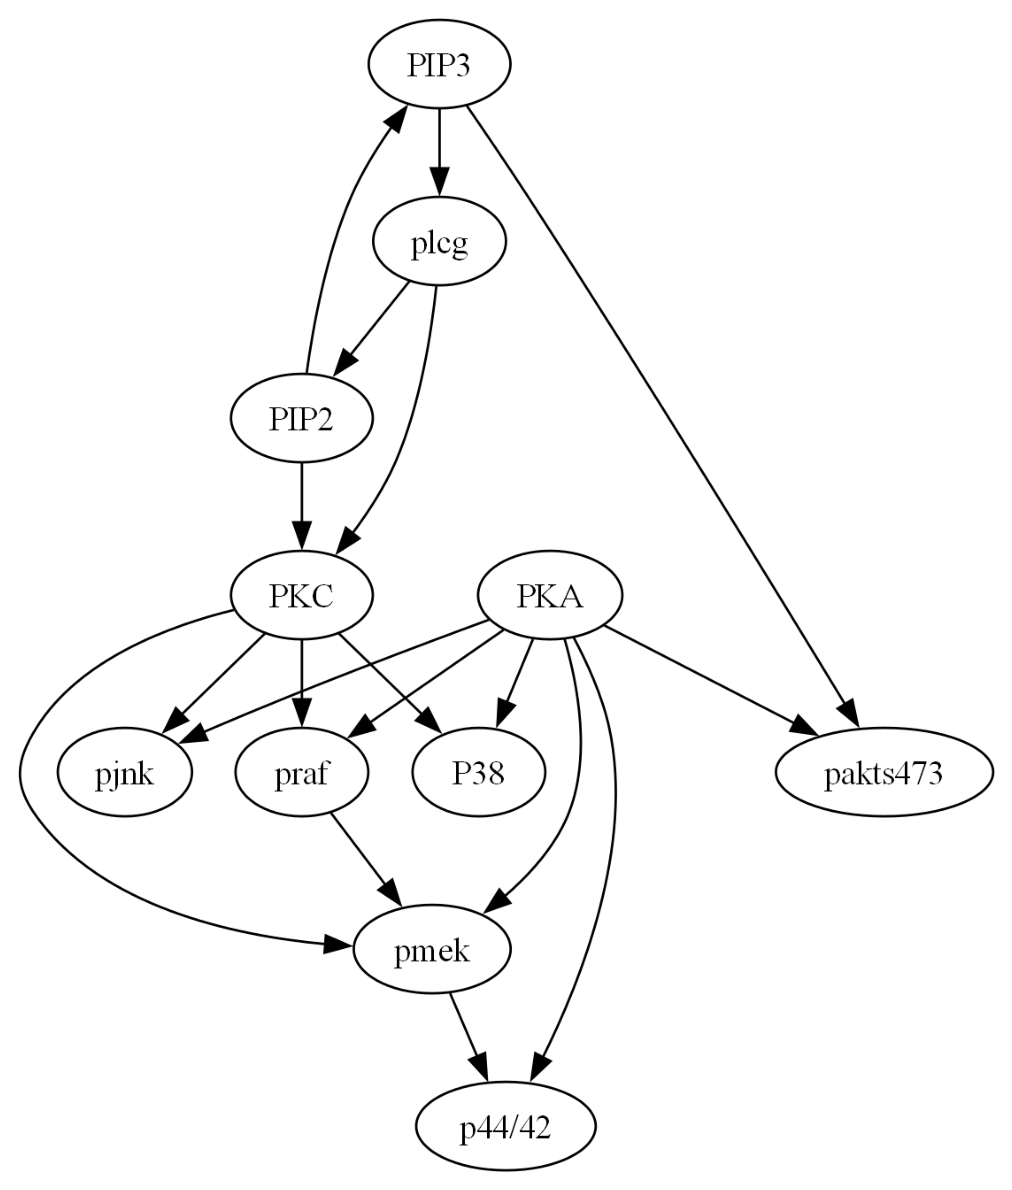

In [152]:
cluster_dag_tiers = make_sachs_cluster_dag()
cluster_dag_tiers.cdag_to_circle_mpdag()
tiers = cluster_dag_tiers.get_cluster_topological_ordering()
fci_tiers_est_graph, fci_tiers_edges = fci_tiers(
    tiers=tiers,
    cluster_mapping=cluster_mapping,
    cdag=cluster_dag_tiers,
    dataset=X,
    alpha=alpha,
    verbose=False,
    show_progress=False,
)
print("FCI-Tiers estimated graph:")
fci_tiers_est_graph.draw_pydot_graph()
true_graph.draw_pydot_graph()